In [575]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [576]:
def plot_fit (x_coord, y_coord, y_sigma, fit_function, minuit_object, title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 0.0, yerr = y_sigma, linestyle = 'None', marker = 'o')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="red", linewidth=2)
    ax.set_xlabel ("t (s)")
    ax.set_ylabel ("V (ohm)")
    ax.set_title (title)

    #plt.savefig("R=5k_cb_C1.png")
    plt.show()
    #plt.close(fig)

In [577]:
C =1.04e-7 #F
C_fit = 1.0308338202525391e-07
erroreC_fit = 6.292667376458447e-10
L_fit = 0.01786042544114515 #H
erroreL_fit = 0.0008195801544976015 #H
Rcriticausata = 500
Rsottosmorzato = 30
Rsovrasmorzato = 2000

In [578]:
#stima di Rcirucito critico
Rcritica= 2*np.sqrt(L_fit/C)
print('resistenza interna circuito RLC critico: ', Rcritica, 'ohm')

resistenza interna circuito RLC critico:  828.8180982845658 ohm


In [579]:
#RLC_critico
def critRLC(t, K, alpha):
    return K * t * np.exp(-alpha * t)

In [580]:
with open('C2RLCcritico.txt') as input_file:
    TLClist = []
    TLCerrlist = []
    VLClist = []
    VLCerrlist = []
    for riga in input_file:
        valoriLC = riga.split()
        TLClist.append(float(valoriLC[0]))
        TLCerrlist.append(float(valoriLC[1]))
        VLClist.append(float(valoriLC[2]))
        VLCerrlist.append(float(valoriLC[3]))

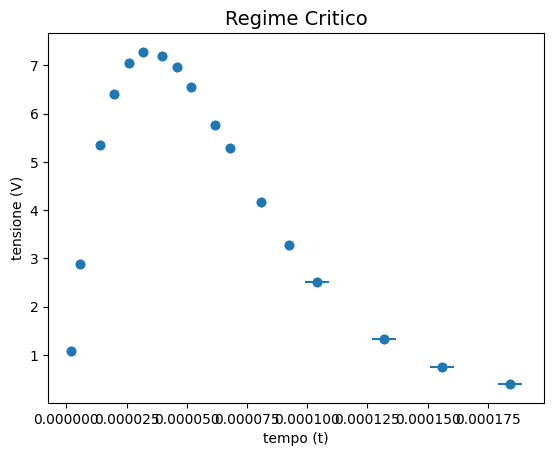

In [581]:
VLC = VLClist
TLC = TLClist

TLC = np.array(TLClist)
VLC = np.array(VLClist)

TLC_err = np.array(TLCerrlist)
VLC_err = np.array(VLCerrlist)


fig, ax = plt.subplots () 
ax.set_title ('Regime Critico', size=14)
ax.set_ylabel ('tensione (V)')
ax.set_xlabel ('tempo (t)')
ax.scatter(TLC, VLC)
ax.errorbar (TLC, VLC, xerr = TLC_err, yerr = VLC_err, linestyle = 'None',marker = 'o')
#plt.savefig("aaa.png")
plt.show()
#plt.close(fig)

In [582]:
least_squares = LeastSquares (TLC, VLC, VLC_err, critRLC)
my_minuit = Minuit (least_squares, K=1., alpha =1.)
#my_minuit.limits["tau"] = (1e-6, None)
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]

print (my_minuit.covariance)


display (my_minuit)

success of the fit:  True
value of the fit Q-squared 66.84291191838155
value of the number of degrees of freedom 15.0
associated p-value:  1.6204572350630997e-08
K = 599824.507 +/- 2442.535
alpha = 30320.428 +/- 83.719
┌───────┬───────────────────┐
│       │        K    alpha │
├───────┼───────────────────┤
│     K │ 5.97e+06    180e3 │
│ alpha │    180e3 7.01e+03 │
└───────┴───────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 66.84 (χ²/ndof = 4.5)      │              Nfcn = 125              │
│ EDM = 2.48e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │  599.8e3  │   2.4e3   │            │            │         │         │       │
│ 1 │ alpha │  30.32e3  │  0.08e3   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │        K    alpha │
├───────┼───────────────────┤
│     K │ 5.97e+06    180e3 │
│ alpha │    180e3 7.01e+03 │
└───────┴───────────────────┘

In [583]:
def dV_dt (t):
    return K_fit * np.exp(-alpha_fit * t) * (1-(alpha_fit*t))
err_crit_RLC = np.sqrt((VLC_err**2) + ((dV_dt(TLC) * TLC_err)**2))

least_squares = LeastSquares (TLC, VLC, err_crit_RLC, critRLC) #!! da corregere l'errore propagato
my_minuit = Minuit (least_squares, K=K_fit, alpha =alpha_fit)
#my_minuit.limits["tau"] = (1e-6, None)
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]

print (my_minuit.covariance)


display (my_minuit)

success of the fit:  True
value of the fit Q-squared 19.423836110940194
value of the number of degrees of freedom 15.0
associated p-value:  0.19516599171035254
K = 598373.695 +/- 3715.242
alpha = 30182.564 +/- 134.954
┌───────┬───────────────────┐
│       │        K    alpha │
├───────┼───────────────────┤
│     K │ 1.38e+07  0.458e6 │
│ alpha │  0.458e6 1.82e+04 │
└───────┴───────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 19.42 (χ²/ndof = 1.3)      │              Nfcn = 47               │
│ EDM = 5.12e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │   598e3   │    4e3    │            │            │         │         │       │
│ 1 │ alpha │  30.18e3  │  0.14e3   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │        K    alpha │
├───────┼───────────────────┤
│     K │ 1.38e+07  0.458e6 │
│ alpha │  0.458e6 1.82e+04 │
└───────┴───────────────────┘

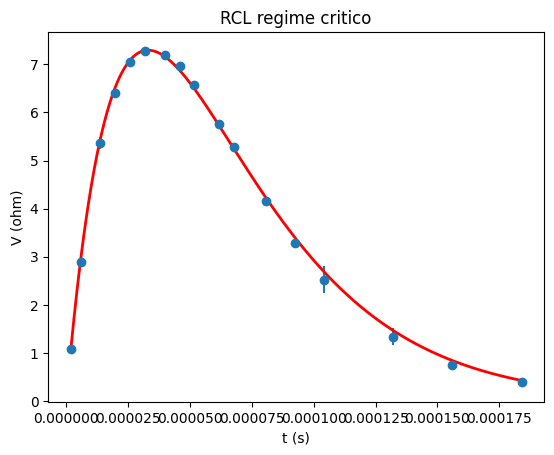

In [584]:
plot_fit(TLC , VLC, err_crit_RLC ,critRLC , my_minuit, "RCL regime critico")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [585]:
#t student
alpha_a = 1/np.sqrt(L_fit*C_fit)
sigma_alpha_a = alpha_a * 0.5 * np.sqrt((erroreL_fit / L_fit)**2 + (erroreC_fit / C_fit)**2)
t_student_alpha_a = (alpha_fit - alpha_a)/(np.sqrt(erralpha**2+sigma_alpha_a**2))
print(sigma_alpha_a)
print('alpha_fit: ', alpha_fit ,'alpha atteso:' , alpha_a, 't student alpha =' , t_student_alpha_a)

#essendo la resistenza sflasata di circa 300 ohm provo a fare questi calcoli
alpha_b= Rcritica/(2*L_fit)
t_student_alpha_b = (alpha_fit - alpha_b)/(np.sqrt(erralpha**2+sigma_alpha_a**2))
print('alpha_fit: ', alpha_fit ,'alpha atteso:' , alpha_b, 't student alpha =' , t_student_alpha_b)
#se sostituisco Rcritica con 500 sperimentale esce anche peggio

539.4343503293416
alpha_fit:  30182.563717365127 alpha atteso: 23305.572229816655 t student alpha = 12.367369449998579
alpha_fit:  30182.563717365127 alpha atteso: 23202.641533252994 t student alpha = 12.552476840992643


In [586]:
# REGIME SOTTOSMORZATO
def undrRLC(t, K, alpha, omega):
    return K * np.exp(-alpha * t) * np.sin(omega * t)

In [587]:
with open('C2RLCsotto.txt') as input_file:
    TLClist1 = []
    TLCerrlist1 = []
    VLClist1 = []
    VLCerrlist1 = []
    for riga in input_file:
        valoriLC = riga.split()
        TLClist1.append(float(valoriLC[0]))
        TLCerrlist1.append(float(valoriLC[1]))
        VLClist1.append(float(valoriLC[2]))
        VLCerrlist1.append(float(valoriLC[3]))

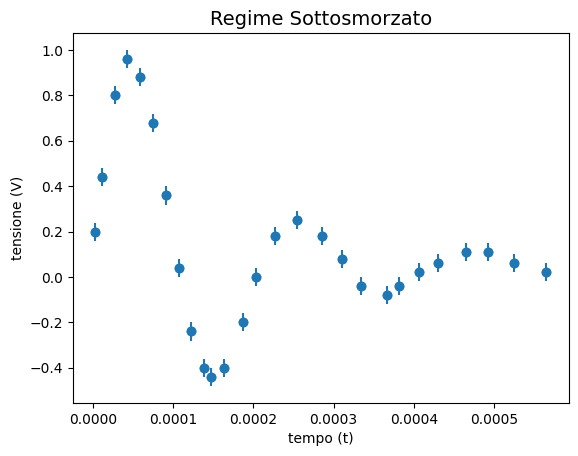

In [588]:
TLC = np.array(TLClist1)
VLC = np.array(VLClist1)
VLC_err = np.array(VLCerrlist1)
TLC_err = np.array(TLClist1)


fig, ax = plt.subplots () 
ax.set_title ('Regime Sottosmorzato', size=14)
ax.set_ylabel ('tensione (V)')
ax.set_xlabel ('tempo (t)')
ax.scatter(TLC, VLC)
ax.errorbar (TLC, VLC, yerr = VLC_err, linestyle = 'None',marker = 'o')
#plt.savefig("aaa.png")
plt.show()
#plt.close(fig)

In [589]:
least_squares = LeastSquares (TLC, VLC, VLC_err, undrRLC)
my_minuit = Minuit (least_squares, K=0.4, alpha =1.2e4, omega = 5.4e4)
#my_minuit.limits["tau"] = (1e-6, None)
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
omega_fit = my_minuit.values[2]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]
erromega = my_minuit.errors[2]

print (my_minuit.covariance)


display (my_minuit)

success of the fit:  True
value of the fit Q-squared 35.83452626356129
value of the number of degrees of freedom 24.0
associated p-value:  0.056949140238466756
K = 1.387 +/- 0.046
alpha = 7251.371 +/- 363.398
omega = 29575.706 +/- 222.812
┌───────┬────────────────────────────┐
│       │        K    alpha    omega │
├───────┼────────────────────────────┤
│     K │  0.00212  13.2588  -1.0064 │
│ alpha │  13.2588 1.32e+05  -0.01e6 │
│ omega │  -1.0064  -0.01e6 4.96e+04 │
└───────┴────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 35.83 (χ²/ndof = 1.5)      │              Nfcn = 146              │
│ EDM = 1.8e-06 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │   1.39    │   0.05    │            │            │         │         │       │
│ 1 │ alpha │   7.3e3   │   0.4e3   │            │            │         │         │       │
│ 2 │ omega │  29.58e3  │  0.22e3   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │        K    alpha    omega │
├───────┼────────────────────────────┤
│     K │  0.00212  13.2588  -1.0064 │
│ alpha │  13.2588 1.32e+05  -0.01e6 │
│ omega │  -1.0064  -0.01e6 4.96e+04 │
└───────┴────────────────────────────┘

In [590]:
def dV_dt (t):
    return K_fit * np.exp(-alpha_fit * t) * (np.cos(omega_fit*t)-(alpha_fit*t*np.sin(omega_fit*t)))
err_undr_RLC = np.sqrt((VLC_err**2) + ((dV_dt(TLC) * TLC_err)**2))

least_squares = LeastSquares (TLC, VLC, err_undr_RLC, undrRLC) #!! da corregere l'errore propagato
my_minuit = Minuit (least_squares, K=K_fit, alpha =alpha_fit, omega = omega_fit)
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
omega_fit = my_minuit.values[2]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]
erromega = my_minuit.errors[2]

print (my_minuit.covariance)


display (my_minuit)

#da capire perchè non cambia chi quad dopo secondo fit

success of the fit:  True
value of the fit Q-squared 35.83442733315277
value of the number of degrees of freedom 24.0
associated p-value:  0.05695039271072733
K = 1.387 +/- 0.046
alpha = 7251.296 +/- 363.389
omega = 29575.904 +/- 222.809
┌───────┬────────────────────────────┐
│       │        K    alpha    omega │
├───────┼────────────────────────────┤
│     K │  0.00212  13.2585  -1.0062 │
│ alpha │  13.2585 1.32e+05  -0.01e6 │
│ omega │  -1.0062  -0.01e6 4.96e+04 │
└───────┴────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 35.83 (χ²/ndof = 1.5)      │              Nfcn = 51               │
│ EDM = 2.04e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │   1.39    │   0.05    │            │            │         │         │       │
│ 1 │ alpha │   7.3e3   │   0.4e3   │            │            │         │         │       │
│ 2 │ omega │  29.58e3  │  0.22e3   │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │        K    alpha    omega │
├───────┼────────────────────────────┤
│     K │  0.00212  13.2585  -1.0062 │
│ alpha │  13.2585 1.32e+05  -0.01e6 │
│ omega │  -1.0062  -0.01e6 4.96e+04 │
└───────┴────────────────────────────┘

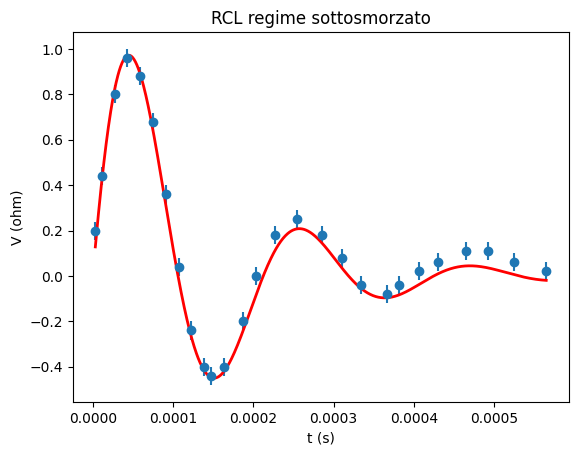

In [591]:
plot_fit(TLC , VLC, err_undr_RLC ,undrRLC , my_minuit, "RCL regime sottosmorzato")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [592]:
L_fitsotto = Rsottosmorzato / (2*alpha_fit)
Csotto = (2 * alpha_fit) / (Rsottosmorzato * (omega_fit**2 + alpha_fit**2))
# Formule per la propagazione degli errori - circuito RLC sottosmorzato

# Errore su L
sigma_L = L_fit * (erralpha/ alpha_fit)

# Errore su C (solo alpha e omega)
sigma_C = C * np.sqrt((erralpha / alpha_fit)**2 + 4 * (omega_fit**2 * erromega**2 + alpha_fit**2 * erralpha**2) / (omega_fit**2 + alpha_fit**2)**2)
print (L_fitsotto, '+/-', sigma_L, Csotto,'+/-', sigma_C)

0.002068595807966879 +/- 0.0008950502577681819 5.213109962273797e-07 +/- 5.449509743084428e-09


In [593]:
#t student
t_student_L_sotto = (-L_fitsotto+L_fit)/np.sqrt(sigma_L**2 + erroreL_fit**2)
t_student_C_sotto = (Csotto-C_fit)/np.sqrt(sigma_C**2 + erroreC_fit**2)
print (t_student_L_sotto, t_student_C_sotto)


13.012377122171257 76.23931783411707


In [594]:
# REGIME SOVRASMORZATO
def ovrRLC(t, K, lamb1, lamb2, t0):
    return K * (np.exp(lamb1 * (t - t0)) - np.exp(lamb2 * (t - t0)))

In [595]:
#RLC_sovra
with open('C2RLCsovra.txt') as input_file:
    TLClist2 = []
    TLCerrlist2 = []
    VLClist2 = []
    VLCerrlist2 = []
    for riga in input_file:
        valoriLC = riga.split()
        TLClist2.append(float(valoriLC[0]))
        TLCerrlist2.append(float(valoriLC[1]))
        VLClist2.append(float(valoriLC[2]))
        VLCerrlist2.append(float(valoriLC[3]))

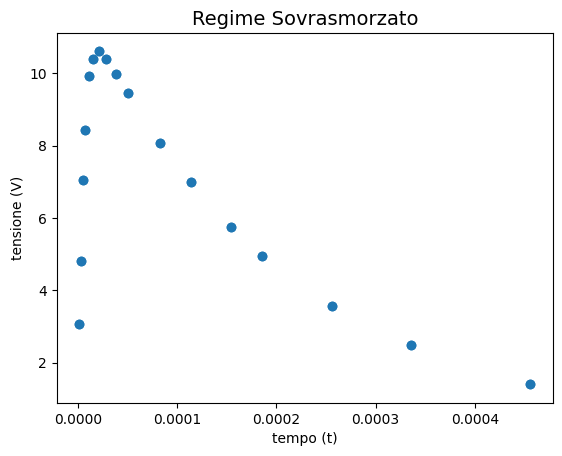

In [596]:
VLC = np.array(VLClist2)
TLC = np.array(TLClist2)
TLC_err = np.array(TLCerrlist2)
VLC_err = np.array(VLCerrlist2)

fig, ax = plt.subplots () 
ax.set_title ('Regime Sovrasmorzato', size=14)
ax.set_ylabel ('tensione (V)')
ax.set_xlabel ('tempo (t)')
ax.scatter(TLC, VLC)
ax.errorbar (TLC, VLC, yerr = VLC_err, linestyle = 'None',marker = 'o')
#plt.savefig("aaa.png")
plt.show()
#plt.close(fig)

In [597]:
least_squares = LeastSquares (TLC, VLC, VLC_err, ovrRLC)
my_minuit = Minuit(least_squares, K=15.0, lamb1=-20000.0, lamb2=-100000.0, t0=-1e-5)
#my_minuit.limits["tau"] = (1e-6, None)
my_minuit.limits["lamb1"] = (None, 0.0)
my_minuit.limits["lamb2"] = (None, 0.0)
my_minuit.limits["t0"] = (None, TLC[0])
my_minuit.migrad ()  
my_minuit.hesse () 


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
lamb1_fit = my_minuit.values[1]
lamb2_fit = my_minuit.values[2]
t0_fit = my_minuit.values[3]
errK = my_minuit.errors[0]
errlamb1 = my_minuit.errors[1]
errlamb2 = my_minuit.errors[2]
errt0 = my_minuit.errors[3]

print (my_minuit.covariance)


display (my_minuit)

success of the fit:  True
value of the fit Q-squared 11.623738000881657
value of the number of degrees of freedom 13.0
associated p-value:  0.5587120216887353
K = 11.938 +/- 0.030
lamb1 = -4705.992 +/- 26.023
lamb2 = -196946.561 +/- 2250.453
t0 = 0.000 +/- 0.000
┌───────┬─────────────────────────────────────────────────────────────────────────┐
│       │                 K             lamb1             lamb2                t0 │
├───────┼─────────────────────────────────────────────────────────────────────────┤
│     K │          0.000898         -572.1e-3           46.4823     -381.8499e-12 │
│ lamb1 │         -572.1e-3               677           -25.4e3    182.7224855e-9 │
│ lamb2 │           46.4823           -25.4e3          5.06e+06 -58.9800956262e-6 │
│    t0 │     -381.8499e-12    182.7224855e-9 -58.9800956262e-6          1.02e-15 │
└───────┴─────────────────────────────────────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 11.62 (χ²/ndof = 0.9)      │              Nfcn = 277              │
│ EDM = 1.82e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │  11.938   │   0.030   │            │            │         │         │       │
│ 1 │ lamb1 │ -4.706e3  │  0.026e3  │            │            │         │    0    │       │
│ 2 │ lamb2 │ -196.9e3  │   2.3e3   │            │            │         │    0    │       │
│ 3 │ t0    │ 0.041e-6  │ 0.032e-6  │            │            │         │ 1.6e-06 │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────────────────────────────────────┐
│       │                 K             lamb1             lamb2                t0 │
├───────┼─────────────────────────────────────────────────────────────────────────┤
│     K │          0.000898         -572.1e-3           46.4823     -381.8499e-12 │
│ lamb1 │         -572.1e-3               677           -25.4e3    182.7224855e-9 │
│ lamb2 │           46.4823           -25.4e3          5.06e+06 -58.9800956262e-6 │
│    t0 │     -381.8499e-12    182.7224855e-9 -58.9800956262e-6          1.02e-15 │
└───────┴─────────────────────────────────────────────────────────────────────────┘

In [598]:
def dV_dt(t):
    return K_fit * (lamb1_fit * np.exp(lamb1_fit * (t - t0_fit)) - lamb2_fit * np.exp(lamb2_fit * (t - t0_fit)))

err_ovr_RLC = np.sqrt((VLC_err**2) + ((dV_dt(TLC) * TLC_err)**2))

least_squares = LeastSquares(TLC, VLC, err_ovr_RLC, ovrRLC)
my_minuit = Minuit(least_squares, K=K_fit, lamb1=lamb1_fit, lamb2=lamb2_fit, t0=t0_fit)

my_minuit.migrad()
my_minuit.hesse()


is_valid = my_minuit.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit.fval, df = my_minuit.ndof))

for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output
    
K_fit = my_minuit.values[0]
alpha_fit = my_minuit.values[1]
omega_fit = my_minuit.values[2]
errK = my_minuit.errors[0]
erralpha = my_minuit.errors[1]
erromega = my_minuit.errors[2]

print (my_minuit.covariance)


display (my_minuit)

#da capire perchè non cambia chi quad dopo secondo fit

success of the fit:  True
value of the fit Q-squared 11.39155728585495
value of the number of degrees of freedom 13.0
associated p-value:  0.5780514573194353
K = 11.938 +/- 0.030
lamb1 = -4705.977 +/- 26.071
lamb2 = -196951.069 +/- 2303.213
t0 = 0.000 +/- 0.000
┌───────┬─────────────────────────────────────────────────────────────────────────┐
│       │                 K             lamb1             lamb2                t0 │
├───────┼─────────────────────────────────────────────────────────────────────────┤
│     K │          0.000906         -575.8e-3           47.7814     -406.9265e-12 │
│ lamb1 │         -575.8e-3               680           -26.0e3    192.9101771e-9 │
│ lamb2 │           47.7814           -26.0e3           5.3e+06 -63.7807057899e-6 │
│    t0 │     -406.9265e-12    192.9101771e-9 -63.7807057899e-6          1.14e-15 │
└───────┴─────────────────────────────────────────────────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 11.39 (χ²/ndof = 0.9)      │              Nfcn = 73               │
│ EDM = 0.000143 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ K     │  11.938   │   0.030   │            │            │         │         │       │
│ 1 │ lamb1 │ -4.706e3  │  0.026e3  │            │            │         │         │       │
│ 2 │ lamb2 │ -197.0e3  │   2.3e3   │            │            │         │         │       │
│ 3 │ t0    │ 0.041e-6  │ 0.034e-6  │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────────────────────────────────────┐
│       │                 K             lamb1             lamb2                t0 │
├───────┼─────────────────────────────────────────────────────────────────────────┤
│     K │          0.000906         -575.8e-3           47.7814     -406.9265e-12 │
│ lamb1 │         -575.8e-3               680           -26.0e3    192.9101771e-9 │
│ lamb2 │           47.7814           -26.0e3           5.3e+06 -63.7807057899e-6 │
│    t0 │     -406.9265e-12    192.9101771e-9 -63.7807057899e-6          1.14e-15 │
└───────┴─────────────────────────────────────────────────────────────────────────┘

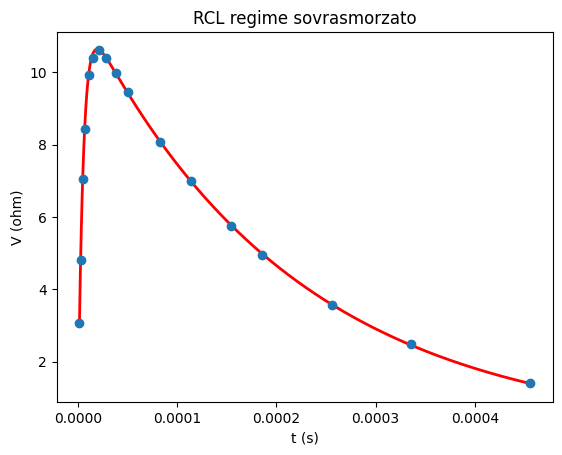

In [599]:
plot_fit(TLC , VLC, err_ovr_RLC ,ovrRLC , my_minuit, "RCL regime sovrasmorzato")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [600]:
L_fitsovra= (-Rsovrasmorzato)/(lamb1_fit+lamb2_fit)
C_fitsovra= -(lamb1_fit+lamb2_fit)/(lamb1_fit*lamb2_fit*Rsovrasmorzato)
# Formule per la propagazione degli errori - circuito RLC sovrasmorzato

# Errore su L
sigma_L = L_fit * np.sqrt(errlamb1**2 + errlamb2**2) / abs(lamb1_fit + lamb2_fit)

# Errore su C
sigma_C = C * np.sqrt((errlamb1**2 + errlamb2**2) / (lamb1_fit + lamb2_fit)**2 + (lamb2_fit**2 * errlamb1**2 + lamb1_fit**2 * errlamb2**2) / (lamb1_fit * lamb2_fit)**2)

print (L_fitsovra, '+/-', sigma_L, C_fitsovra, '+/-', sigma_C)

0.00991804946578306 +/- 0.00019933661751421477 1.0878628343946158e-07 +/- 1.7579149824305729e-09


In [601]:
#t student
t_student_L_sovra = (-L_fitsovra+L_fit)/np.sqrt(sigma_L**2 + erroreL_fit**2)
t_student_C_sovra = (C_fitsovra-C_fit)/np.sqrt(sigma_C**2 + erroreC_fit**2)
print (t_student_L_sovra, t_student_C_sovra)


9.416277570992966 3.05433814900101
